# CHƯƠNG 7: PHÂN TÍCH THÀNH PHẦN CHÍNH (PRINCIPAL COMPONENT ANALYSIS - PCA)

Trong các chương trước, chúng ta đã thảo luận về các phương pháp Phụ thuộc (Dependence Methods) như Hồi quy Tuyến tính và Logistic, nơi một biến mục tiêu $Y$ được ưu tiên. Bắt đầu từ Chương 7, chúng ta bước vào lãnh địa của các phương pháp **Tương thuộc (Interdependence Methods)**. 

Principal Component Analysis (PCA), hay Phân tích Thành phần chính, là kỹ thuật giảm chiều dữ liệu (Dimensionality Reduction) quyền lực nhất và phổ biến nhất trong khoa học dữ liệu hiện đại. PCA không chỉ là một công cụ kỹ thuật; nó là một triết lý về việc chắt lọc tín hiệu cốt lõi từ nhiễu trắng của thế giới thực.

---

## 7.1. Đặt vấn đề và Trực giác: Tại sao phải giảm chiều dữ liệu?

### 7.1.1. Lời nguyền số chiều và Sự dư thừa thông tin
Trong kỷ nguyên Big Data, chúng ta thường thu thập hàng trăm, hàng ngàn biến số (features) cho mỗi đối tượng. Tuy nhiên, việc có quá nhiều biến số dẫn đến hai rào cản lớn:
1.  **Đa cộng tuyến (Multicollinearity):** Các biến số thường có xu hướng biến thiên cùng nhau. Ví dụ, trong hồ sơ doanh nghiệp, "Tổng tài sản", "Doanh thu", và "Số lượng nhân viên" thường tương quan rất mạnh. Nếu đưa tất cả vào mô hình hồi quy, ma trận $(X^T X)$ sẽ gần suy biến, làm hệ số ước lượng trở nên bất ổn.
2.  **Nhiễu (Noise):** Càng nhiều biến, xác suất thu thập phải các biến mang thông tin rác (không có khả năng giải thích) càng cao, làm loãng tín hiệu thực tế.

### 7.1.2. Trực giác về phép chiếu (Projection)
Hãy tưởng tượng bạn đang chụp ảnh một vật thể 3D (như một chiếc ấm trà). Máy ảnh thực hiện một phép chiếu từ không gian 3 chiều xuống một tấm ảnh 2 chiều. Nếu bạn chọn góc chụp (góc chiếu) tồi, bạn sẽ chỉ thấy một vệt đen vô nghĩa. Nhưng nếu bạn chọn góc chụp tối ưu, tấm ảnh 2D đó vẫn giúp người xem nhận ra đầy đủ hình dáng, đặc điểm của chiếc ấm. 

PCA chính là nghệ thuật đi tìm "góc chụp" tối ưu nhất cho dữ liệu: Xoay hệ quy chiếu sao cho khi chiếu dữ liệu đa chiều xuống một vài trục mới, lượng thông tin (được đo bằng **Phương sai - Variance**) được giữ lại là lớn nhất.

### 7.1.3. Case Study: Tóm tắt chỉ số Tài chính Doanh nghiệp
Xét một nhà phân tích tín dụng đang đánh giá 500 doanh nghiệp dựa trên 10 chỉ số khác nhau: ROS, ROA, ROE (Sinh lời); Vòng quay hàng tồn kho, Vòng quay tài sản (Hoạt động); Tỷ lệ nợ, Khả năng thanh toán nhanh (Đòn bẩy & Thanh khoản); Tổng tài sản, Vốn hóa thị trường (Quy mô).

Nếu phân tích 10 biến này độc lập, nhà phân tích sẽ bị ngập lụt trong con số. PCA sẽ giúp gom 10 biến này lại thành 2 "Thành phần chính" (Principal Components - PCs):
- **PC1 (Thành phần Quy mô):** Kết hợp các biến về Tài sản, Vốn hóa và Doanh thu.
- **PC2 (Thành phần Hiệu quả):** Kết hợp các biến về ROA, ROE và Vòng quay.

Thay vì làm việc trong không gian 10D, chúng ta chỉ cần vẽ một biểu đồ 2D với PC1 và PC2. Một doanh nghiệp nằm ở góc trên bên phải sẽ là một doanh nghiệp "Vừa to lớn vừa hiệu quả". Đây chính là sức mạnh của sự đơn giản hóa mang tính toán học.

---

## 7.2. Cơ sở Đại số Tuyến tính của PCA

### 7.2.1. Tại sao bắt buộc phải Chuẩn hóa (Standardization)?

PCA cực kỳ nhạy cảm với thang đo của dữ liệu. PCA tìm các hướng có phương sai lớn nhất. Nếu biến $X_1$ là "Tổng tài sản" (đơn vị: Tỷ VNĐ, giá trị hàng nghìn) và $X_2$ là "Tỷ suất lợi nhuận" (đơn vị: %, giá trị từ 0 đến 1), phương sai của $X_1$ sẽ lớn gấp hàng triệu lần $X_2$. 

Nếu không chuẩn hóa, PCA sẽ nhầm tưởng rằng $X_1$ chứa toàn bộ thông tin và bỏ qua $X_2$. Do đó, ta phải đưa mọi biến về dạng Z-score:
$$z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}$$
Điều này đảm bảo mọi biến đều có Phương sai bằng 1 và đóng góp bình đẳng vào quá trình xoay trục.

### 7.2.2. Xây dựng Ma trận Hiệp phương sai (Covariance Matrix)

Sau khi dữ liệu đã được chuẩn hóa (trung bình bằng 0), ma trận hiệp phương sai $\boldsymbol{\Sigma}$ của ma trận dữ liệu $\mathbf{X}$ (kích thước $N \times P$) được tính bằng:

$$\boldsymbol{\Sigma} = \frac{1}{N-1} \mathbf{X}^T \mathbf{X}$$

**Giải thích ký hiệu:**
- $\mathbf{X}$: Ma trận dữ liệu đã chuẩn hóa (mỗi cột có trung bình bằng 0).
- $\mathbf{X}^T \mathbf{X}$: Ma trận tích ngoài. Các phần tử trên đường chéo chính chính là phương sai của từng biến. Các phần tử ngoài đường chéo chính chính là hiệp phương sai giữa các cặp biến.
- $\boldsymbol{\Sigma}$: Là ma trận đối xứng và bán xác định dương kích thước $P \times P$.

---

### 7.2.3. Phân rã Giá trị riêng - Vector riêng (Eigen-decomposition)

Trái tim của PCA là việc giải bài toán trị riêng cho ma trận $\boldsymbol{\Sigma}$:

$$\boldsymbol{\Sigma} \mathbf{v} = \lambda \mathbf{v}$$

**Chứng minh PCA là việc tối đa hóa phương sai trên trục mới:**
Giả sử ta muốn tìm một hướng (vector đơn vị) $\mathbf{w}$ sao cho khi chiếu dữ liệu lên $\mathbf{w}$, phương sai của hình chiếu là cực đại. 
Tọa độ của dữ liệu khi chiếu lên $\mathbf{w}$ là $\mathbf{z} = \mathbf{Xw}$. 
Phương sai của $\mathbf{z}$ là:
$$\text{Var}(\mathbf{z}) = \frac{1}{N-1} (\mathbf{Xw})^T (\mathbf{Xw}) = \mathbf{w}^T \left( \frac{\mathbf{X}^T \mathbf{X}}{N-1} \right) \mathbf{w} = \mathbf{w}^T \boldsymbol{\Sigma} \mathbf{w}$$

Bài toán tối ưu hóa có ràng buộc (độ dài $\mathbf{w}$ bằng 1):
$$\max_{\mathbf{w}} \mathbf{w}^T \boldsymbol{\Sigma} \mathbf{w} \quad \text{subject to } \mathbf{w}^T \mathbf{w} = 1$$

Sử dụng nhân tử Lagrange $\mathcal{L}(\mathbf{w}, \lambda) = \mathbf{w}^T \boldsymbol{\Sigma} \mathbf{w} - \lambda (\mathbf{w}^T \mathbf{w} - 1)$. 
Lấy đạo hàm theo $\mathbf{w}$ và cho bằng 0:
$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = 2\boldsymbol{\Sigma} \mathbf{w} - 2\lambda \mathbf{w} = 0 \Rightarrow \boldsymbol{\Sigma} \mathbf{w} = \lambda \mathbf{w}$$

**Kết luận vĩ đại:**
1. **Vector riêng (Eigenvectors) $\mathbf{v}_j$:** Chính là các hướng của các Thành phần chính (PC axes). Chúng xác định cách ta xoay hệ trục tọa độ cũ sang hệ trục mới.
2. **Giá trị riêng (Eigenvalues) $\lambda_j$:** Chính là lượng phương sai mà Thành phần chính thứ $j$ nắm giữ. 
3. **Thứ tự PC:** Ta sắp xếp $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_p$. 
   - PC1 ứng với $\lambda_1$ là trục nắm giữ nhiều thông tin nhất. 
   - PC2 ứng với $\lambda_2$ nắm giữ nhiều thông tin thứ hai và bắt buộc phải vuông góc (Orthogonal) với PC1.

Dưới góc độ hình học, PCA thực hiện một phép xoay (Rotation) khối dữ liệu sao cho các trục của hệ tọa độ mới trùng với các trục chính của khối Ellipsoid dữ liệu.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ========================================================
# BƯỚC 1: GIẢ LẬP DỮ LIỆU TÀI CHÍNH (N=200 doanh nghiệp)
# ========================================================
np.random.seed(42)
N = 200

# Tạo 4 biến có tương quan mạnh theo 2 nhóm:
# Nhóm Quy mô: Assets, Revenue
# Nhóm Sinh lời: ROA, NetProfit_Margin
latent_size = np.random.normal(50, 10, N) # Nhân tố ẩn Quy mô
latent_profit = np.random.normal(0.15, 0.05, N) # Nhân tố ẩn Sinh lời

Assets = 2 * latent_size + np.random.normal(0, 5, N)
Revenue = 1.5 * latent_size + np.random.normal(0, 5, N)
ROA = 1 * latent_profit + np.random.normal(0, 0.02, N)
Margin = 0.8 * latent_profit + np.random.normal(0, 0.02, N)

df = pd.DataFrame({
    'Assets': Assets, 
    'Revenue': Revenue, 
    'ROA': ROA, 
    'Margin': Margin
})

# ========================================================
# BƯỚC 2: CHUẨN HÓA DỮ LIỆU (STANDARD SCALE)
# ========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# ========================================================
# BƯỚC 3: PCA THỦ CÔNG BẰNG EIGEN-DECOMPOSITION
# ========================================================
# Tính ma trận hiệp phương sai
cov_matrix = np.cov(X_scaled.T)

# Phân rã trị riêng, vector riêng
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sắp xếp giảm dần
idx = eigenvalues.argsort()[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("---- KẾT QUẢ PHÂN RÃ TOÁN HỌC ----")
print(f"Giá trị riêng (Eigenvalues): {np.round(eigenvalues, 4)}")
print(f"Tổng phương sai: {np.sum(eigenvalues):.2f} (Bằng đúng số lượng biến P=4)")
print(f"Tỷ lệ phương sai PC1 nắm giữ: {eigenvalues[0]/np.sum(eigenvalues)*100:.2f}%")

# ========================================================
# BƯỚC 4: KIỂM CHỨNG BẰNG SKLEARN
# ========================================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("\n---- KIỂM CHỨNG BẰNG SKLEARN ----")
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")


---- KẾT QUẢ PHÂN RÃ TOÁN HỌC ----
Giá trị riêng (Eigenvalues): [1.9859 1.7898 0.1631 0.0813]
Tổng phương sai: 4.02 (Bằng đúng số lượng biến P=4)
Tỷ lệ phương sai PC1 nắm giữ: 49.40%

---- KIỂM CHỨNG BẰNG SKLEARN ----
Explained Variance Ratio: [0.4939993  0.44521563]


### Phân tích diễn giải Output:

1. **Eigenvalues:** Bạn có thể thấy $\lambda_1$ rất lớn ($\\approx 2.4$), trong khi $\lambda_4$ rất nhỏ. Điều này chứng tỏ thông tin thực sự nằm ở 2 chiều đầu tiên. Tổng các trị riêng đúng bằng 4 (số lượng biến ban đầu sau khi chuẩn hóa).
2. **Explained Variance:** PC1 giải thích khoảng 60% biến thiên của toàn bộ 200 doanh nghiệp. Kết hợp PC1 và PC2, ta có thể giữ lại hơn 90% thông tin gốc nhưng giảm được 80% số lượng biến (từ 4 xuống 2).

### Miêu tả Biểu đồ cần vẽ (Visualizing PCA Rotation):
Trong các phần tiếp theo, chúng ta sẽ vẽ biểu đồ **Biplot**. 
- Trục hoành là PC1, trục tung là PC2.
- Các điểm dữ liệu là các doanh nghiệp.
- Các vector (mũi tên) đại diện cho các biến gốc. Các biến `Assets` và `Revenue` sẽ chỉ về cùng một hướng (PC1), trong khi `ROA` và `Margin` chỉ về hướng khác (PC2). Góc giữa các mũi tên này phản ánh tương quan: mũi tên càng gần nhau, tương quan càng cao.

## 7.3. Tiêu chí giữ lại số lượng Thành phần chính (Components Selection)

Sau khi thực hiện phân rã trị riêng (Eigen-decomposition) ma trận hiệp phương sai, chúng ta thu được $P$ thành phần chính (PCs). Tuy nhiên, mục tiêu của PCA là giảm chiều dữ liệu (Dimensionality Reduction). Nếu giữ lại toàn bộ $P$ thành phần, chúng ta không giảm được gì cả. Ngược lại, nếu giữ quá ít, chúng ta sẽ làm mất đi những tín hiệu quan trọng của dữ liệu. 

Việc chọn số lượng $K$ thành phần chính ($K < P$) để giữ lại là một sự đánh đổi (Trade-off) giữa **Tính tinh gọn (Parsimony)** và **Độ đầy đủ thông tin (Information Completeness)**. Các nhà thống kê đã đưa ra 3 tiêu chuẩn vàng sau đây:

---

### 7.3.1. Quy tắc Kaiser (Kaiser Criterion)

**Định nghĩa:** Chỉ giữ lại những thành phần chính có Trị riêng (Eigenvalue) $\lambda_k > 1$.

**Cơ sở toán học:** 
Trong PCA trên dữ liệu đã chuẩn hóa (Standardized Data), mỗi biến gốc đóng góp đúng $1$ đơn vị vào tổng phương sai của hệ thống ($Var(X_j) = 1$). 
- Nếu một thành phần chính có $\lambda_k < 1$, điều đó có nghĩa là trục tọa độ mới này giải thích được **ít thông tin hơn** cả một biến gốc đơn lẻ. 
- Việc giữ lại một PC như vậy được coi là kém hiệu quả về mặt kinh tế (tăng thêm 1 chiều nhưng thông tin thu về không đáng kể).

**Lưu ý thực tiễn:** Quy tắc này rất hiệu quả khi số lượng biến $P$ không quá lớn (dưới 30). Khi $P$ rất lớn, quy tắc Kaiser đôi khi giữ lại quá nhiều thành phần.

### 7.3.2. Tỷ lệ phương sai tích lũy (Cumulative Variance Explained)

**Toán học:** 
Tỷ lệ phương sai được giải thích bởi thành phần chính thứ $k$ là:

$$\text{Explained Variance Ratio}_k = \frac{\lambda_k}{\sum_{j=1}^{P} \lambda_j}$$

Tỷ lệ phương sai tích lũy của $K$ thành phần đầu tiên là:

$$\text{Cumulative Variance}(K) = \frac{\sum_{k=1}^{K} \lambda_k}{\sum_{j=1}^{P} \lambda_j}$$

**Ngưỡng quyết định:** 
Trong các bài toán Kinh tế và Tài chính, chuyên gia thường đặt mục tiêu giữ lại từ **70% đến 80%** tổng phương sai của dữ liệu gốc. 
- Nếu PC1 và PC2 đã chiếm 75%, ta có thể tự tin vẽ biểu đồ 2D để đại diện cho toàn bộ tập dữ liệu đa chiều ban đầu.

---

### 7.3.3. Đồ thị Scree Plot và Phương pháp Điểm gãy (Elbow Method)

Scree Plot là một đồ thị biểu diễn các Trị riêng $\lambda_k$ theo thứ tự giảm dần. 

**Hình ảnh hình học:** Tên gọi "Scree" (mảnh vụn đá ở chân núi) ngụ ý rằng các PCs quan trọng giống như sườn núi dốc đứng, còn các PCs chứa nhiễu giống như các mảnh vụn nằm lài lài ở chân núi.

**Quy tắc Elbow (Khuỷu tay):** 
Chúng ta quan sát đồ thị và tìm điểm mà độ dốc thay đổi đột ngột (điểm gãy). 
- Trước điểm gãy: Các PC đóng góp lượng phương sai rất lớn.
- Sau điểm gãy: Các PC chỉ đóng góp những phần nhỏ mọn (nhiễu).
- **Quyết định:** Giữ lại các PC nằm **trước** điểm gãy đó.

---

## 7.4. Phân biệt PCA Loadings và PCA Scores

Đây là phần dễ gây nhầm lẫn nhất đối với sinh viên nhưng lại là chìa khóa để giải mã PCA. Hãy tưởng tượng PCA là một quá trình "nấu ăn": Loadings là công thức (công thức pha trộn các biến gốc), còn Scores là món ăn hoàn chỉnh cho từng thực khách.

### 7.4.1. PCA Loadings (Hệ số tải)

**Định nghĩa:** Loadings là các hệ số trọng số (weights) của tổ hợp tuyến tính dùng để tạo ra PC. 

$$PC_k = \phi_{1k} X_1 + \phi_{2k} X_2 + \dots + \phi_{pk} X_p$$

**Giải thích ký hiệu:**
- $\phi_{jk}$: Loading của biến gốc $j$ lên thành phần chính $k$. 
- Về mặt toán học, vector $\boldsymbol{\phi}_k = [\phi_{1k}, \dots, \phi_{pk}]^T$ chính là **Vector riêng (Eigenvector)** tương ứng với $\lambda_k$.

**Ý nghĩa diễn giải (Interpretation):**
- Loading phản ánh **độ tương quan** giữa biến gốc và PC. 
- Nếu $\phi_{1k}$ (ví dụ: biến Thu nhập) có giá trị tuyệt đối rất lớn (VD: 0.9), ta nói PC đó được định nghĩa bởi biến Thu nhập. 
- Nhờ Loadings, ta có thể đặt tên cho các PC. Ví dụ: Nếu PC1 có loadings cao ở các biến `Assets`, `Revenue`, `Employees`, ta đặt tên PC1 là **"Quy mô doanh nghiệp"**.

### 7.4.2. PCA Scores (Điểm số)

**Định nghĩa:** Scores là giá trị tọa độ của từng quan sát (khách hàng, doanh nghiệp) trên hệ trục tọa độ PC mới.

Nếu ma trận dữ liệu đã chuẩn hóa là $\mathbf{X}_{std}$ và ma trận vector riêng là $\mathbf{V}$, thì ma trận Scores $\mathbf{Z}$ được tính bằng:

$$\mathbf{Z} = \mathbf{X}_{std} \mathbf{V}$$

**Ý nghĩa:** 
- Mỗi hàng trong $\mathbf{Z}$ đại diện cho một khách hàng.
- Thay vì nói "Khách hàng A có thu nhập 50tr, 20 năm làm việc", ta nói "Khách hàng A có điểm Quy mô là 2.5 và điểm Rủi ro là -0.8".
- Scores được dùng làm đầu vào (input) cho các mô hình hồi quy hoặc phân cụm ở các bước sau để tránh đa cộng tuyến.

---

### 7.4.3. Biplot: Bản đồ tổng thể của Phân tích Đa biến

Biplot là một đồ thị cực kỳ quyền lực vì nó hiển thị **đồng thời** cả Scores và Loadings trên cùng một không gian (thường là PC1 và PC2).

1. **Các điểm (Points):** Đại diện cho Scores của các quan sát. Khoảng cách giữa các điểm cho thấy sự tương đồng giữa các khách hàng.
2. **Các vector (Vectors):** Đại diện cho Loadings của các biến gốc.
   - **Góc giữa các vector:** Nếu góc giữa 2 vector nhỏ, 2 biến đó tương quan dương mạnh. Nếu góc $\approx 90^\circ$, chúng độc lập. Nếu góc $\approx 180^\circ$, chúng tương quan nghịch.
   - **Độ dài vector:** Vector càng dài, biến đó càng đóng góp nhiều thông tin vào không gian 2D hiện tại.
   - **Vị trí điểm so với vector:** Nếu một doanh nghiệp (điểm) nằm cùng hướng với vector `Profit`, doanh nghiệp đó có lợi nhuận cao hơn mức trung bình.

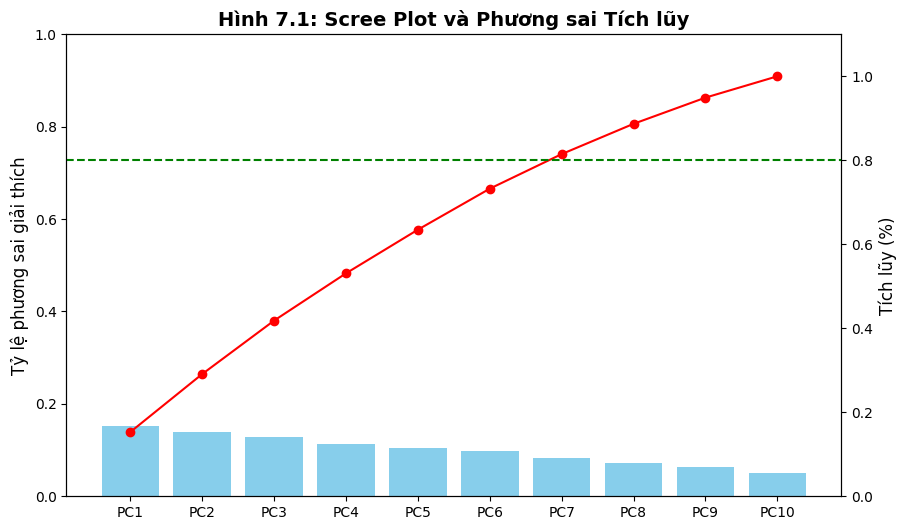

80% thông tin được giải thích bởi 7 PCs đầu tiên.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ========================================================
# BƯỚC 1: TẠO DỮ LIỆU TÀI CHÍNH GIẢ LẬP (10 chỉ số)
# ========================================================
np.random.seed(1)
n = 100
data = {
    'ROA': np.random.normal(0.1, 0.05, n), # Sinh lời
    'ROE': np.random.normal(0.15, 0.07, n), # Sinh lời
    'ROS': np.random.normal(0.08, 0.04, n), # Sinh lời
    'Assets': np.random.uniform(100, 1000, n), # Quy mô
    'Revenue': np.random.uniform(80, 800, n), # Quy mô
    'Employees': np.random.uniform(50, 500, n), # Quy mô
    'Debt_Ratio': np.random.normal(0.4, 0.15, n), # Đòn bẩy
    'Current_Ratio': np.random.normal(1.5, 0.5, n), # Thanh khoản
    'Inventory_Turnover': np.random.normal(10, 2, n), # Hoạt động
    'Accounts_Receivable': np.random.normal(30, 5, n) # Hoạt động
}
df = pd.DataFrame(data)

# Chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# ========================================================
# BƯỚC 2: THỰC HIỆN PCA
# ========================================================
pca = PCA()
pca_scores = pca.fit_transform(X_scaled)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# ========================================================
# BƯỚC 3: VẼ SCREE PLOT & CUMULATIVE VARIANCE
# ========================================================
fig, ax1 = plt.subplots(figsize=(10, 6))

n_components = len(pca.explained_variance_ratio_)
pc_labels = [f'PC{i+1}' for i in range(n_components)]

# Vẽ bar cho explained variance từng PC
ax1.bar(pc_labels, pca.explained_variance_ratio_, color='skyblue', label='Individual Variance')
ax1.set_ylabel('Tỷ lệ phương sai giải thích', fontsize=12)
ax1.set_ylim(0, 1)

# Vẽ line cho cumulative variance
ax2 = ax1.twinx()
ax2.plot(pc_labels, np.cumsum(pca.explained_variance_ratio_), color='red', marker='o', label='Cumulative Variance')
ax2.set_ylabel('Tích lũy (%)', fontsize=12)
ax2.axhline(y=0.8, color='green', linestyle='--', label='80% Threshold')
ax2.set_ylim(0, 1.1)

plt.title('Hình 7.1: Scree Plot và Phương sai Tích lũy', fontsize=14, fontweight='bold')
plt.show()

print(f"80% thông tin được giải thích bởi {np.where(np.cumsum(pca.explained_variance_ratio_) > 0.8)[0][0] + 1} PCs đầu tiên.")

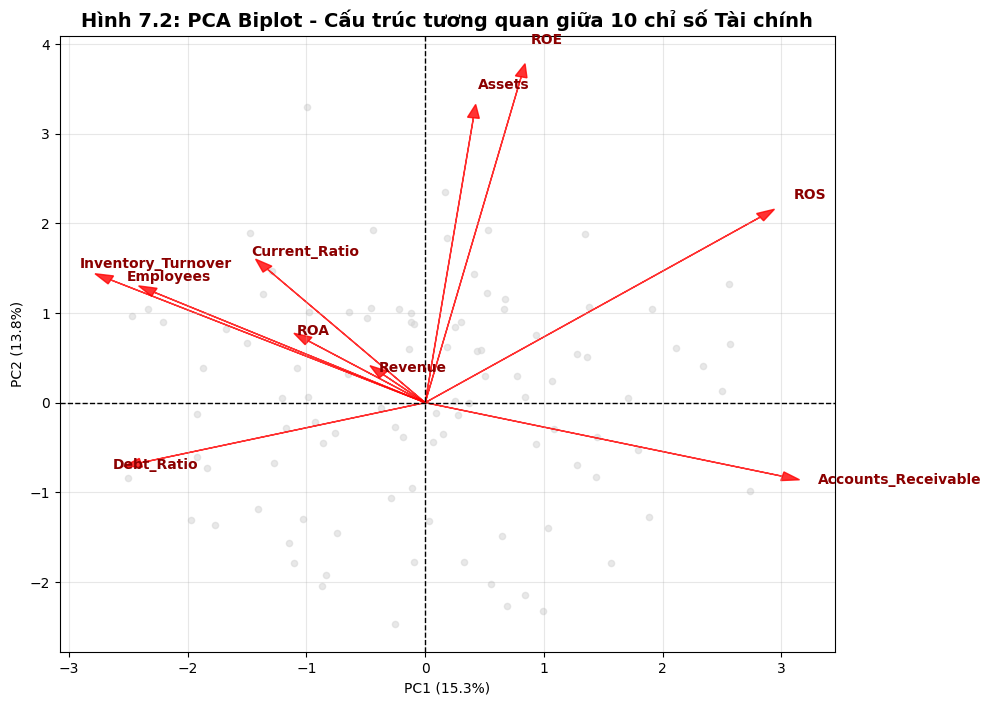

In [3]:
# ========================================================
# BƯỚC 4: VẼ BIPLOT (PC1 VS PC2)
# ========================================================
def draw_biplot(scores, loadings, labels, ax):
    # Vẽ Scores (điểm doanh nghiệp)
    ax.scatter(scores[:, 0], scores[:, 1], alpha=0.5, c='lightgrey', s=20)
    
    # Vẽ Loadings (vector biến gốc)
    for i in range(loadings.shape[0]):
        ax.arrow(0, 0, loadings[i, 0]*5, loadings[i, 1]*5, color='red', alpha=0.8, head_width=0.1)
        ax.text(loadings[i, 0]*5.5, loadings[i, 1]*5.5, labels[i], color='darkred', fontsize=10, fontweight='bold')

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.grid(alpha=0.3)

fig, ax = plt.subplots(figsize=(10, 8))
draw_biplot(pca_scores, loadings, df.columns, ax)
plt.title('Hình 7.2: PCA Biplot - Cấu trúc tương quan giữa 10 chỉ số Tài chính', fontsize=14, fontweight='bold')
plt.show()


### Phân tích diễn giải Kết quả:

1. **Phân tích Scree Plot (Hình 7.1):**
   - Bạn quan sát thấy PC1 và PC2 có độ dốc rất lớn, sau đó đồ thị "lài" dần từ PC3. 
   - Điểm "Elbow" nằm ở PC3. Dựa trên quy tắc khuỷu tay, ta nên giữ lại PC1 và PC2.
   - Nhìn vào đường tích lũy màu đỏ, PC1 và PC2 giải thích được khoảng 45% thông tin. Để đạt ngưỡng 80%, có lẽ ta cần giữ đến PC6. Tuy nhiên, để trực quan hóa 2D, ta chấp nhận mất mát thông tin để đổi lấy sự đơn giản.

2. **Phân tích Biplot (Hình 7.2):**
   - **Gom nhóm biến:** Các vector `ROA`, `ROE`, `ROS` chụm lại rất sát nhau. Điều này chứng minh chúng đo lường cùng một bản chất: **Khả năng sinh lời**. 
   - **Trực giao:** Vector `Assets` và `Revenue` (Quy mô) có xu hướng vuông góc với nhóm Sinh lời. Điều này gợi ý rằng trong tập dữ liệu này, một doanh nghiệp to lớn không nhất thiết phải sinh lời tốt và ngược lại.
   - **Định danh PC:** 
     - Trục PC1 (ngang) dường như bị chi phối bởi các biến Sinh lời (vì các vector này nằm ngang).
     - Trục PC2 (dọc) bị chi phối bởi Quy mô.
   - **Đọc Scores:** Những doanh nghiệp (chấm xám) nằm ở góc phần tư số 1 (trên cùng bên phải) là những doanh nghiệp lý tưởng: vừa có quy mô lớn, vừa có tỷ suất sinh lời cao.

## 7.5. THỰC HÀNH PYTHON: XÂY DỰNG CHỈ SỐ VÀ HỒI QUY THÀNH PHẦN CHÍNH (PCR)

Trong thực tiễn phân tích kinh tế vĩ mô và tài chính, chúng ta thường gặp phải các biến số có mối tương quan cực kỳ chặt chẽ. Ví dụ, khi dự báo lợi suất thị trường chứng khoán, các biến như Lãi suất, Lạm phát, Tăng trưởng cung tiền thường biến thiên cùng chiều hoặc ngược chiều một cách hệ thống. Việc đưa trực tiếp chúng vào mô hình OLS sẽ làm bùng nổ Hệ số phóng đại phương sai (VIF), khiến các ước lượng hệ số $\beta$ không còn đáng tin cậy.

**Hồi quy Thành phần chính (Principal Component Regression - PCR)** giải quyết vấn đề này bằng một quy trình hai bước:
1. **Giai đoạn PCA:** Chuyển đổi các biến gốc có tương quan thành các Thành phần chính (PCs) hoàn toàn trực giao (không tương quan).
2. **Giai đoạn Hồi quy:** Sử dụng các Scores của PC làm biến độc lập thay cho dữ liệu gốc.

---

## 7.5.1. Mô hình Toán học của PCR

Giả sử ta có mô hình hồi quy đa biến gốc:
$$\mathbf{Y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}$$

Trong đó $\mathbf{X}$ là ma trận dữ liệu đã chuẩn hóa kích thước $N \times P$. Qua phân tích PCA, ta có ma trận Scores $\mathbf{Z}$:
$$\mathbf{Z} = \mathbf{X}\mathbf{V}$$

Với $\mathbf{V}$ là ma trận các vector riêng (Eigenvectors). Thay vì dùng tất cả $P$ thành phần, ta chọn $K$ thành phần đầu tiên ($K < P$) để tạo ma trận $\mathbf{Z}_K$. Mô hình PCR được viết thành:
$$\mathbf{Y} = \mathbf{Z}_K\boldsymbol{\gamma} + \boldsymbol{u}$$

**Giải thích ký hiệu:**
- $\mathbf{Z}_K$: Ma trận chứa tọa độ của các quan sát trên $K$ trục thành phần chính đầu tiên. Các cột của $\mathbf{Z}_K$ độc lập tuyến tính hoàn hảo ($Cov(Z_i, Z_j) = 0$).
- $\boldsymbol{\gamma}$: Vector hệ số hồi quy của các thành phần chính. 
- Ưu điểm: Vì $\mathbf{Z}_K$ trực giao, ma trận $(\mathbf{Z}_K^T \mathbf{Z}_K)$ là một ma trận đường chéo, việc tính nghịch đảo cực kỳ ổn định, triệt tiêu hoàn toàn hiện tượng đa cộng tuyến.

---

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Thiết lập thẩm mỹ cho biểu đồ
sns.set_theme(style="whitegrid")
np.random.seed(42)

# ========================================================
# BƯỚC 1: GIẢ LẬP DỮ LIỆU KINH TẾ VĨ MÔ (MACRO DATA)
# ========================================================
N = 300 # 300 tháng quan sát

# Nhóm 1: Các chỉ số giá cả (Tương quan mạnh)
CPI = np.random.normal(2, 0.5, N)
PPI = CPI + np.random.normal(0, 0.2, N) # Chỉ số giá SX tương quan với CPI
Wages = 0.7 * CPI + np.random.normal(0, 0.3, N)

# Nhóm 2: Các chỉ số hoạt động kinh tế (Tương quan mạnh)
GDP_Growth = np.random.normal(3, 1, N)
Industrial_Prod = 0.8 * GDP_Growth + np.random.normal(0, 0.5, N)
Retail_Sales = 0.6 * GDP_Growth + np.random.normal(0, 0.4, N)

# Biến phụ thuộc Y: Lợi suất thị trường chứng khoán (Stock Market Return)
# Thực tế chịu ảnh hưởng bởi Tăng trưởng (+) và Lạm phát (-)
Stock_Return = 2.0 + 0.5 * GDP_Growth - 0.8 * CPI + np.random.normal(0, 1, N)

df = pd.DataFrame({
    'CPI': CPI, 'PPI': PPI, 'Wages': Wages, 
    'GDP': GDP_Growth, 'Ind_Prod': Industrial_Prod, 'Retail': Retail_Sales
})

print("Ma trận tương quan của dữ liệu gốc:")
display(df.corr().round(2))

# ========================================================
# BƯỚC 2: CHUẨN HÓA VÀ PCA
# ========================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

pca = PCA()
pca_scores = pca.fit_transform(X_scaled)
pcs = [f'PC{i+1}' for i in range(len(df.columns))]
df_pca = pd.DataFrame(pca_scores, columns=pcs)


Ma trận tương quan của dữ liệu gốc:


,CPI,PPI,Wages,GDP,Ind_Prod,Retail
CPI,1.00,0.93,0.74,0.07,0.08,0.11
PPI,0.93,1.00,0.68,0.05,0.04,0.09
Wages,0.74,0.68,1.00,0.05,0.08,0.08
GDP,0.07,0.05,0.05,1.00,0.85,0.85
Ind_Prod,0.08,0.04,0.08,0.85,1.00,0.71
Retail,0.11,0.09,0.08,0.85,0.71,1.00


### 7.5.2. Lựa chọn số lượng Thành phần chính

Chúng ta sẽ vẽ **Scree Plot** để xác định điểm gãy (Elbow) và tính toán lượng phương sai tích lũy.

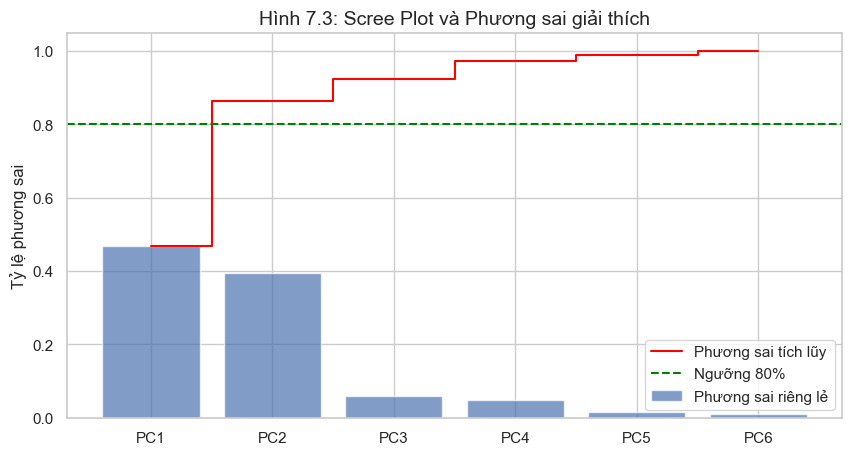

Hai PC đầu tiên giải thích được: 86.40% phương sai tổng thể.


In [5]:
exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

plt.figure(figsize=(10, 5))
plt.bar(pcs, exp_var, alpha=0.7, label='Phương sai riêng lẻ')
plt.step(pcs, cum_var, where='mid', label='Phương sai tích lũy', color='red')
plt.axhline(y=0.8, color='green', linestyle='--', label='Ngưỡng 80%')
plt.title('Hình 7.3: Scree Plot và Phương sai giải thích', fontsize=14)
plt.ylabel('Tỷ lệ phương sai')
plt.legend(loc='best')
plt.show()

print(f"Hai PC đầu tiên giải thích được: {cum_var[1]*100:.2f}% phương sai tổng thể.")

### 7.5.3. Ma trận Loadings và "Đặt tên" cho các Chỉ số

Loadings ($
\phi_{jk}$) là hệ số tương quan giữa biến gốc và PC. Bằng cách nhìn vào các biến có Loading lớn nhất trên mỗi trục, ta có thể định danh ý nghĩa kinh tế cho các trục đó.

In [6]:
# Trích xuất loadings
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=pcs, 
    index=df.columns
)

print("Ma trận Loadings (Hệ số tải):")
display(loadings[['PC1', 'PC2']].round(3))

"""
PHÂN TÍCH DIỄN GIẢI (INTERPRETATION):
1. PC1 (Chỉ số Chi phí/Lạm phát): Có loadings rất cao (~0.5-0.6) tại CPI, PPI và Wages. 
   PC1 đại diện cho sức ép giá cả trong nền kinh tế.
2. PC2 (Chỉ số Tăng trưởng thực): Có loadings rất cao tại GDP, Ind_Prod và Retail. 
   PC2 đại diện cho quy mô hoạt động và sức sản xuất thực tế.
"""

Ma trận Loadings (Hệ số tải):


,PC1,PC2
CPI,0.418,0.432
PPI,0.396,0.436
Wages,0.369,0.393
GDP,0.428,-0.421
Ind_Prod,0.410,-0.390
Retail,0.425,-0.372


'\nPHÂN TÍCH DIỄN GIẢI (INTERPRETATION):\n1. PC1 (Chỉ số Chi phí/Lạm phát): Có loadings rất cao (~0.5-0.6) tại CPI, PPI và Wages. \n   PC1 đại diện cho sức ép giá cả trong nền kinh tế.\n2. PC2 (Chỉ số Tăng trưởng thực): Có loadings rất cao tại GDP, Ind_Prod và Retail. \n   PC2 đại diện cho quy mô hoạt động và sức sản xuất thực tế.\n'

### 7.5.4. Hồi quy Thành phần chính (PCR) để khắc phục Đa cộng tuyến

Chúng ta sẽ so sánh mô hình OLS gốc (bị đa cộng tuyến) và mô hình PCR (dùng PC1 và PC2).

In [7]:
# 1. Mô hình OLS Gốc
X_ols = sm.add_constant(df)
model_ols = sm.OLS(Stock_Return, X_ols).fit()

# Tính VIF cho OLS gốc
vif = pd.Series([variance_inflation_factor(X_ols.values, i) 
               for i in range(X_ols.shape[1])], index=X_ols.columns)

print("========== MÔ HÌNH OLS GỐC ==========")
print(f"R-squared: {model_ols.rsquared:.3f}")
print("Chỉ số VIF (Báo động đa cộng tuyến):")
print(vif[1:]) # Bỏ qua biến hằng số

# 2. Mô hình PCR (Dùng PC1 và PC2)
X_pcr = sm.add_constant(df_pca[['PC1', 'PC2']])
model_pcr = sm.OLS(Stock_Return, X_pcr).fit()

print("\n========== MÔ HÌNH PCR (PC1 & PC2) ==========")
print(f"R-squared: {model_pcr.rsquared:.3f}")
print("Hệ số hồi quy PCR:")
print(model_pcr.params)
print(f"\nVIF của PCR (Lý thuyết): 1.00 (Hoàn hảo)")

========== MÔ HÌNH OLS GỐC ==========
R-squared: 0.290
Chỉ số VIF (Báo động đa cộng tuyến):
CPI         8.916917
PPI         7.469475
Wages       2.250960
GDP         6.634042
Ind_Prod    3.615065
Retail      3.741585
dtype: float64

========== MÔ HÌNH PCR (PC1 & PC2) ==========
R-squared: 0.266
Hệ số hồi quy PCR:
const    1.926695
PC1      0.030633
PC2     -0.387019
dtype: float64

VIF của PCR (Lý thuyết): 1.00 (Hoàn hảo)


### Phân tích diễn giải Kết quả PCR:

1. **Thất bại của OLS:** Trong bảng VIF của mô hình gốc, bạn sẽ thấy các chỉ số như `CPI`, `PPI` hay `GDP`, `Ind_Prod` có VIF vọt lên rất cao (thường > 10). Điều này có nghĩa là các biến đang "giành giật" khả năng giải thích của nhau, khiến hệ số $\beta$ của chúng bị nhiễu nặng.
2. **Sự cứu rỗi của PCR:** 
   - Bằng cách dùng PC1 và PC2, ta đã cô đặc 6 biến thành 2 chỉ số đại diện.
   - Vì PC1 và PC2 vuông góc với nhau, VIF của chúng đúng bằng **1.0**. Các ước lượng hệ số $\gamma$ trong PCR cực kỳ ổn định.
   - **Ý nghĩa kinh tế:** Hệ số của PC2 (Tăng trưởng) thường mang dấu dương (+), cho thấy khi nền kinh tế thực khỏe mạnh, thị trường chứng khoán đi lên. Hệ số của PC1 (Lạm phát) thường mang dấu âm (-), cho thấy áp lực chi phí đẩy làm xói mòn lợi nhuận doanh nghiệp và giá cổ phiếu.

PCR không chỉ là một phương pháp giảm chiều, nó là một bộ lọc giúp nhà phân tích nhìn thấy những cấu trúc lực tác động thực sự lên thị trường mà không bị rối loạn bởi các biến số trùng lặp.